<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellmender import denoise_count_matrix
# except ImportError:
#     print("cellmender not found, installing...")
#     !pip install -U -q cellmender[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellmender import denoise_count_matrix
from cellmender.simulation import simulate_cells
import cellmender.utils as cm_utils
from cellmender.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping

cellmender_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellmender"

# import importlib
# import cellmender.celltype_ambient
# importlib.reload(cellmender.celltype_ambient)
# from cellmender.celltype_ambient import denoise_count_matrix

# import importlib
# import cellmender.utils.visualization_utils as visualization_utils
# importlib.reload(visualization_utils)
# from cellmender.utils.visualization_utils import plot_cross_species_histogram

# Compare CellBender vs. cellmender

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k?

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k, hgmm12k, tiny_cellbender, simulation1, custom
rerun_tools = True  # rerun tools if files don't exist OR if overwrite=True (else download from Box) - if True, requires docker
wompwomp_path = os.path.join(os.path.dirname(cellmender_dir), "wompwomp")  # only needed if dataset_name == "custom"
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = True  # overwrite existing files
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = True
threads = 8

# only required if dataset_name == "custom"; if using a dataset option above, then this will override the defaults filled out below
adata_path_raw_custom = None
adata_path_cellmender_custom = None
adata_path_cellbender_custom = None
soupx_out_prefix_custom = None
decontx_out_prefix_custom = None
adata_path_scar_custom = None
sequencing_technology_custom = None
model_pkl_custom = None
matrix_tar_files_dir_custom = None
raw_tar_file_dir_custom = None
filtered_tar_file_dir_custom = None
cellmender_max_iter_custom = None
cellmender_beta_custom = None
cellmender_cell_ambient_fraction_custom = None
cellbender_epochs_custom = None
cellbender_fpr_custom = None
cellbender_zdim_custom = None
cellbender_expected_cells_custom = None
scar_epochs_custom = None
cellbender_total_droplets_custom = None
expected_cells_custom = None
cs_empty_threshold_custom = None
min_genes_custom = None
min_cells_custom = None
umi_top_percentile_to_remove_custom = None
fraction_doublet_custom = None
unique_genes_top_percentile_to_remove_custom = None
mt_gene_percentile_to_remove_custom = None
max_mt_percentage_custom = None
n_top_genes_custom = None
n_pcs_custom = None
n_neighbors_custom = None
leiden_resolution_custom = None
marker_genes_custom = None

In [4]:
data_dir = os.path.join(cellmender_dir, "notebooks", "data", f"{dataset_name}_tmp")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellmender_dir, "notebooks", "output", f"{dataset_name}_tmp")
os.makedirs(out_dir, exist_ok=True)

cellmender_matrix_url = None
cellbender_matrix_url = None
cellbender_matrix_filtered_url = None
cellbender_ckpt_url = None
soupx_matrix_url = None
decontx_matrix_url = None
scar_matrix_url = None

cellmender_log_file = os.path.join(data_dir, "cellmender.log")
cellbender_ckpt = os.path.join(out_dir, "cellbender_ckpt.tar.gz")

if dataset_name == "tiny_cellbender":
    adata_path_raw = f"{data_dir}/tiny_raw_feature_bc_matrix.h5ad"
    adata_path_cellmender = f"{data_dir}/tiny_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/tiny_output_cellbender.h5"
    soupx_out_prefix = None  # f"{data_dir}/tiny_output_soupx"
    decontx_out_prefix = None  # f"{data_dir}/tiny_output_decontx"
    adata_path_scar = None
    sequencing_technology = "10XV2"
    model_pkl = "Adult_Mouse_Gut.pkl"  # path to celltypist model pkl file - this is a mouse heart dataset, but this is really just for debugging anyways
    
    if not os.path.exists(adata_path_raw):
        raise FileNotFoundError(f"Original matrix file not found: {adata_path_raw}. Create with CellBender's `python generate_tiny_10x_dataset.py` (see https://github.com/broadinstitute/CellBender):")
    
    matrix_tar_files_dir = None
    raw_tar_file_dir = None
    filtered_tar_file_dir = None

    cellmender_matrix_url = None
    cellbender_matrix_url = None
    cellbender_matrix_filtered_url = None
    cellbender_ckpt_url = None
    soupx_matrix_url = None
    decontx_matrix_url = None

    cellmender_max_iter = 10
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 2
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_expected_cells = None
    cellbender_total_droplets = None
    scar_epochs = 2
    expected_cells = 500
    cs_empty_threshold = 1000
    min_genes = 5
    min_cells = 3
    umi_top_percentile_to_remove = None
    fraction_doublet = None
    unique_genes_top_percentile_to_remove = None
    mt_gene_percentile_to_remove = None
    max_mt_percentage = 50
    n_top_genes = 2000
    n_pcs = 45
    n_neighbors = 15
    leiden_resolution = 1.0
    marker_genes = {
        'Resting CD4+ T cells': ["Hbb-bs", "mt-Co3", "mt-Atp6"],
        'Paneth.progenitor': ["Eef1a1"],
        'Plasma cell': ["H3f3b"],
        'Naive B cells': ["Rpl13", "Rplp0"]
    }
elif dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    adata_path_cellmender = f"{data_dir}/pbmc8k_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/pbmc8k_output_cellbender.h5"
    soupx_out_prefix = f"{data_dir}/pbmc8k_output_soupx"
    decontx_out_prefix = f"{data_dir}/pbmc8k_output_decontx"
    adata_path_scar = f"{data_dir}/pbmc8k_output_scar.h5ad"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path to celltypist model pkl file

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir) and rerun_tools:
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir) and rerun_tools:
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

    cellmender_matrix_url = "https://caltech.box.com/shared/static/dltpt6ixhvzg0rb6h1058aamrcmi7oy7.h5ad"
    cellbender_matrix_url = "https://caltech.box.com/shared/static/trxd26eqmr33cg3ot0l3jins9s193ob6.h5"
    cellbender_matrix_filtered_url = "https://caltech.box.com/shared/static/bnilabzuvdvtm1knpsfgy89php938qft.h5"
    cellbender_ckpt_url = "https://caltech.box.com/shared/static/hj41un9dz0pk5j10t8dyfj2mbllzrp6s.gz"
    soupx_matrix_url = "https://caltech.box.com/shared/static/7lhpw8bgwf3b3gyl7wgqe15h3yhxamld.gz"
    decontx_matrix_url = "https://caltech.box.com/shared/static/zzfs06lp634g2rhuuph200rvga08atzh.gz"
    scar_matrix_url = "https://caltech.box.com/shared/static/jhg1yd0kaao0atsyzs1yfne25dkqwz4f.h5ad"
    
    cellmender_max_iter = 500
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_expected_cells = None
    cellbender_total_droplets = None
    scar_epochs = 200
    expected_cells = 8381
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 5
    fraction_doublet = 0.15
    unique_genes_top_percentile_to_remove = 5
    mt_gene_percentile_to_remove = 10
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 1.0
    marker_genes = {
        "Monocytes/neutrophils": ["S100A8", "S100A9", "S100A12", "FCGR3A"],
        "Monocytes/pDCs": ["LYZ", "CST3", "FCN1", "LILRA4"],
        "T": ["IL32", "TRAC", "CCR7", "FOXP3", "CD8A", "CD8B", "NKG7", "GNLY", "TRGC1", "SLC4A10"],
        "B": ["IGHD", "CD79A", "FCER2", "TNFRSF13B"],
        "NK": ["KLRF1", "SPON2"],
        "Progenitor": ["PPBP"],
        "Baso./neutro./progenitor": ["SDPR", "CLU"],
        "(Broad expression)": ["PTPRC"]
    }
elif dataset_name == "hgmm12k":
    adata_path_raw = f"{data_dir}/hgmm_12k_raw_gene_bc_matrices_h5.h5"
    adata_path_cellmender = f"{data_dir}/hgmm_12k_output_cellmender.h5ad"
    adata_path_cellbender = f"{data_dir}/hgmm_12k_output_cellbender.h5"
    soupx_out_prefix = f"{data_dir}/hgmm_12k_output_soupx"
    decontx_out_prefix = f"{data_dir}/hgmm_12k_output_decontx"
    adata_path_scar = f"{data_dir}/hgmm_12k_output_scar.h5ad"
    sequencing_technology = "10XV2"
    model_pkl = None

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/hgmm_12k/hgmm_12k_raw_gene_bc_matrices_h5.h5
    
    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "hg19")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "hg19")
    if not os.path.exists(raw_tar_file_dir) and rerun_tools:
        raw_tar_path = os.path.join(matrix_tar_files_dir, "hgmm_12k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/hgmm_12k/hgmm_12k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir) and rerun_tools:
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "hgmm_12k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/hgmm_12k/hgmm_12k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}

    cellmender_matrix_url = "https://caltech.box.com/shared/static/asrt7vgt7lnhazcjujkil1ak1v9y6qo5.h5ad"
    cellbender_matrix_url = "https://caltech.box.com/shared/static/p3v6ader1i27jcj5xhwfcmg1w8dkp158.h5"
    cellbender_matrix_filtered_url = "https://caltech.box.com/shared/static/0dma5qrc94tbi07pic0w8c0b50jxmach.h5"
    cellbender_ckpt_url = "https://caltech.box.com/shared/static/esz6du1ti0wakqc1j2y1gzg445zllcw5.gz"
    soupx_matrix_url = "https://caltech.box.com/shared/static/mt9us648ol61hdol3mohrpg1t658quqv.gz"
    decontx_matrix_url = "https://caltech.box.com/shared/static/2hrjra6dcw92om90wgz4vwbkcebtt5r8.gz"
    scar_matrix_url = "https://caltech.box.com/shared/static/8m3zmvqajy4tpui5c2jhxjr8q6pfoqg7.h5ad"
    
    cellmender_max_iter = 500
    cellmender_beta = 0.03
    cellmender_cell_ambient_fraction = 0.01
    cellbender_epochs = 150
    cellbender_fpr = 0.01
    cellbender_zdim = 64
    cellbender_total_droplets = None
    scar_epochs = 200
    expected_cells = 12820
    cs_empty_threshold = 10
    min_genes = 0
    min_cells = 0
    umi_top_percentile_to_remove = 0
    fraction_doublet = None
    unique_genes_top_percentile_to_remove = 0
    mt_gene_percentile_to_remove = 0
    max_mt_percentage = None
    n_top_genes = 2000
    n_pcs = 25
    n_neighbors = 20
    leiden_resolution = 1.0
    marker_genes = None

    matrix_tar_files_dir = os.path.join(matrix_tar_files_dir, "combined")
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "combined")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "combined")
    adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
    umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, show=False)
    adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    paths = cm_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="combined", write_raw=True, write_filtered=True)
    
    # # soupx inputs
    # matrix_tar_files_dir = matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix
    #!!! continue filling out

# elif dataset_name == "simulation1":
#     if not os.path.exists(adata_path_raw):
#         adata = cm_utils.simulate_cells(adata_path_raw, ...)
    
#     paths = cm_utils.write_10x_like(adata, matrix_tar_files_dir)

#     # # soupx inputs
#     # matrix_tar_files_dir = matrix_tar_files_dir
#     adata_soupx_obs_csv = paths["celltypes"]
#     # soupx_out_prefix

#     # # decontx inputs
#     raw_tar_file_dir = paths["raw"]
#     filtered_tar_file_dir = paths["filtered"]
#     sequencing_technology = paths["technology"]
#     # decontx_out_prefix
#     #!!! continue filling out

# set any custom variables provided by the user
for var in ["adata_path_raw", "adata_path_cellmender", "adata_path_cellbender", "soupx_out_prefix", "decontx_out_prefix", "sequencing_technology", "model_pkl", "matrix_tar_files_dir", "raw_tar_file_dir", "filtered_tar_file_dir", "cellmender_max_iter", "cellmender_beta", "cellmender_cell_ambient_fraction", "cellbender_epochs", "cellbender_fpr", "cellbender_expected_cells", "cellbender_zdim", "cellbender_total_droplets", "scar_epochs", "expected_cells", "cs_empty_threshold", "min_genes", "min_cells", "umi_top_percentile_to_remove", "fraction_doublet","unique_genes_top_percentile_to_remove", "mt_gene_percentile_to_remove", "max_mt_percentage", "n_top_genes", "n_pcs", "n_neighbors", "leiden_resolution", "marker_genes"]:
    custom = globals().get(f"{var}_custom")
    if custom is not None:
        globals()[var] = custom

adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")

--2025-11-22 12:46:18--  https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32549555 (31M) [binary/octet-stream]
Saving to: ‘/data/cellmender/notebooks/data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5’

/data/cellmender/no 100%[===================>]  31.04M  96.6MB/s    in 0.3s    

2025-11-22 12:46:19 (96.6 MB/s) - ‘/data/cellmender/notebooks/data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5’ saved [32549555/32549555]



## Raw

In [5]:
adata_raw = cm_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

12:46:19 - INFO - Loading adata from '/data/cellmender/notebooks/data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Knee plot - use this output to estimate cs_empty_threshold

UMI cutoff for expected cells (8381): 1386.00


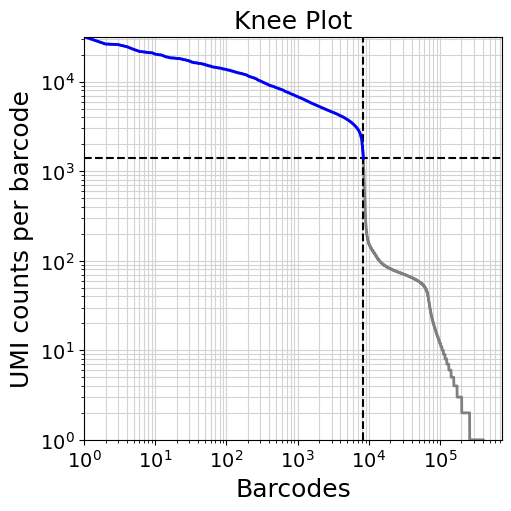

In [6]:
umi_cutoff = cm_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [7]:
# umi_cutoff = 0  #!!! optionally update from knee plot
adata_raw = cm_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

In [8]:
if dataset_name == "hgmm12k" and 'celltype' not in adata_raw.obs:
    adata_raw.obs['hg19_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'hg19'].X.sum(axis=1)).ravel()
    adata_raw.obs['mm10_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'mm10'].X.sum(axis=1)).ravel()
    adata_raw.obs['genome'] = np.where(adata_raw.obs['hg19_total_counts'] >= adata_raw.obs['mm10_total_counts'], 'hg19', 'mm10')  # predict genome
    adata_raw.obs['celltype'] = adata_raw.obs['genome']

    adata_raw = cm_utils.detect_doublets_human_mouse(adata_raw, fraction_doublet=0.15, plot_empty=False, umi_cutoff=umi_cutoff, expected_cells=expected_cells, out_path=os.path.join(out_dir, "hgmm12k_doublet_detection.png"), show=False)

MALAT1: 219203.0
B2M: 106492.0
TMSB4X: 102342.0
EEF1A1: 69831.0
RPS27: 62948.0
RPL21: 57949.0
RPL13: 53520.0
RPL13A: 50325.0
RPL10: 49660.0
RPS18: 44868.0


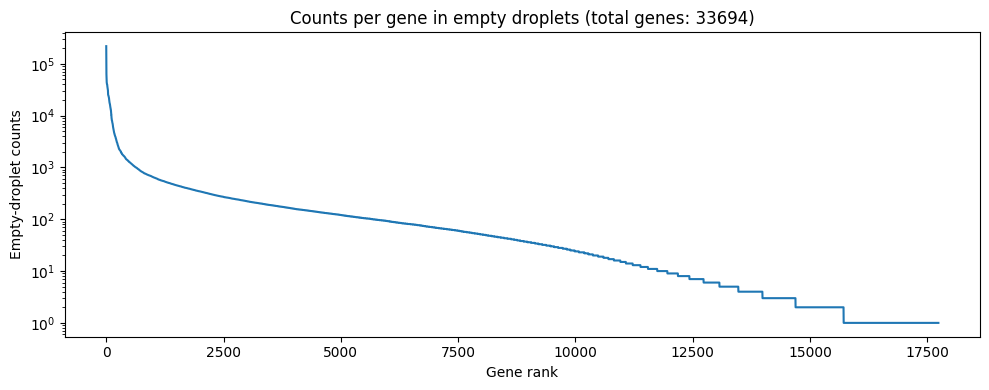

In [9]:
cm_utils.plot_empty_gene_counts(adata_raw, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
cm_utils.print_top_empty_genes(adata_raw, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

## CellBender (v0.3.0)

In [10]:
cellbender_expected_cells = None
cellbender_total_droplets = None

if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          ckpt_out_path = os.path.join(data_dir, "cellbender_ckpt.tar.gz").replace(f"{cellmender_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
print(adata_cellbender)

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5 --output /data/pbmc8k_tmp/pbmc8k_output_cellbender.h5 --epochs 150 --fpr 0.01 --z-dim 64 --model full --cuda
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 0ac41fc077)
cellbender:remove-background: 2025-11-22 20:46:25
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4024
cellbender:remove-background: Prior on counts for empty droplets is 72
cellbender:remove-background: Excluding 7778 features that are estimated to have

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [11]:
cellbender_expected_cells = 8381
cellbender_total_droplets = None

if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          ckpt_out_path = os.path.join(data_dir, "cellbender_ckpt.tar.gz").replace(f"{cellmender_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
print(adata_cellbender)

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5 --expected-cells 8381 --output /data/pbmc8k_tmp/pbmc8k_output_cellbender.h5 --epochs 150 --fpr 0.01 --z-dim 64 --model full --cuda
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 9f2e721df7)
cellbender:remove-background: 2025-11-22 21:09:26
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4220
cellbender:remove-background: Prior on counts for empty droplets is 73
cellbender:remove-background: Excluding 6757 features that

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
cellbender_expected_cells = 8381
cellbender_total_droplets = 12000

if not os.path.exists(adata_path_cellbender) or overwrite:
     if rerun_tools:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellmender_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellmender_dir}/notebooks/data", "/data")
          ckpt_out_path = os.path.join(data_dir, "cellbender_ckpt.tar.gz").replace(f"{cellmender_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !docker run --rm {gpus} -v {cellmender_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender} {cellbender_matrix_url}
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
print(adata_cellbender)

cellbender:remove-background: Command:
cellbender remove-background --input /data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5 --expected-cells 8381 --total-droplets-included 12000 --output /data/pbmc8k_tmp/pbmc8k_output_cellbender.h5 --epochs 150 --fpr 0.01 --z-dim 64 --model full --cuda
cellbender:remove-background: CellBender 0.3.0
cellbender:remove-background: (Workflow hash 6607513855)
cellbender:remove-background: 2025-11-22 21:41:46
cellbender:remove-background: Running remove-background
cellbender:remove-background: Loading data from /data/pbmc8k_tmp/pbmc8k_raw_gene_bc_matrices_h5.h5
cellbender:remove-background: CellRanger v2 format
cellbender:remove-background: Features in dataset: 33694 NA
cellbender:remove-background: Trimming features for inference.
cellbender:remove-background: 21719 features have nonzero counts.
cellbender:remove-background: Prior on counts for cells is 4220
cellbender:remove-background: Prior on counts for empty droplets is 124
cellbender:remove-backgro

/home/jrich/miniconda3/envs/cellmender/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
